# Introducción

En este proyecto, trabajaremos como analistas de datos para Zuber, una empresa de viajes compartidos que opera en la ciudad de Chicago. Nuestro objetivo es:

- Analizar patrones de comportamiento en los viajes realizados durante noviembre de 2017.

- Explorar las condiciones climáticas y su posible impacto en la duración de los trayectos.

- Probar una hipótesis estadística sobre si el clima lluvioso afecta la duración de los viajes entre dos barrios clave: Loop y el Aeropuerto Internacional O'Hare.

Para lograr esto, utilizaremos datos extraídos previamente mediante SQL desde una base de datos que contiene información sobre empresas de taxis, barrios, viajes y registros meteorológicos.

Contamos con tres datasets en formato CSV:

- ('/datasets/project_sql_result_01.csv'): Empresas de taxis y número de viajes (15 y 16 de noviembre)

- ('/datasets/project_sql_result_04.csv'): Promedio de viajes por barrio en noviembre

- ('/datasets/project_sql_result_07.csv'): Viajes del Loop al aeropuerto con información del clima

A continuación, realizaremos un análisis exploratorio de los datos y, posteriormente, aplicaremos una prueba de hipótesis para obtener conclusiones basadas en evidencias estadísticas.

In [1]:
# Importar librerias para el proyecto
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

In [2]:
# Cargar los datasets
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')
df_weather_trips = pd.read_csv('/datasets/project_sql_result_07.csv')

# Imprimir la información de cada dataset
print("Empresas de taxis (trips_amount por compañía):")
df_companies.info()
print('-'*60)

print("Barrios por promedio de viajes en noviembre:")
df_neighborhoods.info()
print('-'*60)

print("Viajes del Loop al aeropuerto con clima:")
df_weather_trips.info()


Empresas de taxis (trips_amount por compañía):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
------------------------------------------------------------
Barrios por promedio de viajes en noviembre:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
------------------------------------------------------------
Viajes del Loop al aeropuerto con clima:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries,

In [3]:
# Visualizar las primeras filas de cada dataset
print("Empresas de taxis (trips_amount por compañía):")
display(df_companies.head())
print('-'*60)

print("\nBarrios por promedio de viajes en noviembre:")
display(df_neighborhoods.head())
print('-'*60)

print("\nViajes del Loop al aeropuerto con clima:")
display(df_weather_trips.head())

Empresas de taxis (trips_amount por compañía):


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


------------------------------------------------------------

Barrios por promedio de viajes en noviembre:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


------------------------------------------------------------

Viajes del Loop al aeropuerto con clima:


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


Ahora convirtamos el tipo de dato de la columna '`start_ts`'. También creamos dos columnas nuevas: una para almacenar solo la fecha del viaje y la otra, la hora de recogida.

In [4]:
# Cambiar la columna 'start_ts' al formato datetime del dataset df_weather_trips 
df_weather_trips['start_ts'] = pd.to_datetime(df_weather_trips['start_ts'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
df_weather_trips['start_date'] = df_weather_trips ['start_ts'].dt.date
df_weather_trips['start_time'] = df_weather_trips ['start_ts'].dt.time

# Imprimir la información del dataset con el nuevo formato
df_weather_trips.info()
print()
df_weather_trips.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
 3   start_date          1068 non-null   object        
 4   start_time          1068 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 41.8+ KB



,start_ts,weather_conditions,duration_seconds,start_date,start_time
0,2017-11-25 16:00:00,Good,2410.0,2017-11-25,16:00:00
1,2017-11-25 14:00:00,Good,1920.0,2017-11-25,14:00:00
2,2017-11-25 12:00:00,Good,1543.0,2017-11-25,12:00:00
3,2017-11-04 10:00:00,Good,2512.0,2017-11-04,10:00:00
4,2017-11-11 07:00:00,Good,1440.0,2017-11-11,07:00:00


Para facilitar el análisis de los viajes según su fecha y hora de inicio, convertimos la columna start_ts al formato datetime. A partir de esta columna derivamos tres nuevas variables:

- start_date: contiene solo la fecha (año, mes y día), útil para agrupar por días completos.

- start_day: contiene únicamente el día del mes, útil para identificar fácilmente días específicos (por ejemplo, todos los sábados de noviembre).

- start_time: contiene solo la hora, útil si se desea analizar los viajes por franjas horarias.

Estas transformaciones nos permitirán realizar agrupaciones, filtros y análisis temporales con mayor flexibilidad.

In [5]:
df_weather_trips['start_date'] = df_weather_trips['start_ts'].dt.date    # Fecha completa
df_weather_trips['start_day'] = df_weather_trips['start_ts'].dt.day      # Solo día
df_weather_trips['start_time'] = df_weather_trips['start_ts'].dt.time    # Hora

df_weather_trips.head()

,start_ts,weather_conditions,duration_seconds,start_date,start_time,start_day
0,2017-11-25 16:00:00,Good,2410.0,2017-11-25,16:00:00,25
1,2017-11-25 14:00:00,Good,1920.0,2017-11-25,14:00:00,25
2,2017-11-25 12:00:00,Good,1543.0,2017-11-25,12:00:00,25
3,2017-11-04 10:00:00,Good,2512.0,2017-11-04,10:00:00,4
4,2017-11-11 07:00:00,Good,1440.0,2017-11-11,07:00:00,11


También parece que los tiempos de viaje solo se registraron hasta horas, para corroborar que si es cierto vamos hacer el conteo de cada hora.

In [6]:
# Mostrar los recuentos de los valores en la columna 'start_time'
display(df_weather_trips['start_time'].value_counts().sort_index().to_frame())

,start_time
00:00:00,2
01:00:00,1
02:00:00,1
03:00:00,4
04:00:00,20
05:00:00,36
06:00:00,96
07:00:00,63
08:00:00,88
09:00:00,42


De hecho, no hay registro de los minutos y segundos de la hora de inicio del recorrido. Para simplificar, extraigamos también la hora y la guardemos como una nueva columna.

In [7]:
# Extraemos la hora del campo 'start_ts' y la guardamos en una nueva columna 'start_hour'.
# Esto nos permitirá analizar los viajes según la hora del día, ya que los registros están redondeados a la hora.
df_weather_trips['start_hour'] = df_weather_trips['start_ts'].dt.hour

df_weather_trips.head()

,start_ts,weather_conditions,duration_seconds,start_date,start_time,start_day,start_hour
0,2017-11-25 16:00:00,Good,2410.0,2017-11-25,16:00:00,25,16
1,2017-11-25 14:00:00,Good,1920.0,2017-11-25,14:00:00,25,14
2,2017-11-25 12:00:00,Good,1543.0,2017-11-25,12:00:00,25,12
3,2017-11-04 10:00:00,Good,2512.0,2017-11-04,10:00:00,4,10
4,2017-11-11 07:00:00,Good,1440.0,2017-11-11,07:00:00,11,7


## Identificación de los 10 principales barrios por finalización de viajes

Para entender qué barrios fueron los destinos más frecuentes en noviembre de 2017, vamos a identificar los 10 principales barrios con mayor promedio de viajes finalizados. Para ello, ordenamos el dataset df_neighborhoods por la columna average_trips en orden descendente y seleccionamos los primeros 10 registros. Estos barrios nos dan una idea clara de las zonas más populares o concurridas durante ese periodo.

In [8]:
# Ordenar el dataset por la columna 'average_trips' de forma descendente
top_10_neighborhoods = df_neighborhoods.sort_values(by = 'average_trips', ascending = False).head(10)

# Mostrar los 10 principales barrios
display(top_10_neighborhoods)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


A continuación, se construye un gráfico de barras para visualizar los 10 barrios con mayor promedio de viajes finalizados durante noviembre de 2017. Este gráfico permite identificar fácilmente cuáles fueron los destinos más comunes de los viajes en taxi en la ciudad de Chicago en ese mes. La visualización facilita la comparación entre los barrios de manera intuitiva.

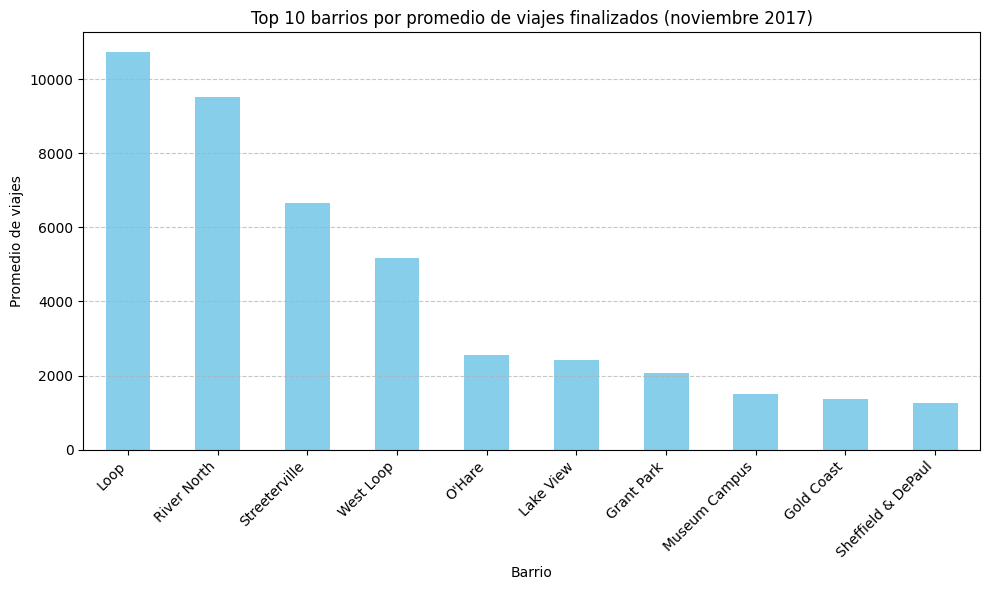

In [9]:
# Gráfico de barras de los 10 principales barrios
top_10_neighborhoods.plot(kind = 'bar', x = 'dropoff_location_name', y = 'average_trips', legend = False, figsize = (10, 6), color = 'skyblue')

plt.title('Top 10 barrios por promedio de viajes finalizados (noviembre 2017)')
plt.ylabel('Promedio de viajes')
plt.xlabel('Barrio')
plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

Del gráfico se observa que los barrios con mayor promedio de finalizaciones de viajes son áreas céntricas y de alto tránsito, como Loop, River North y Streeterville. Esto sugiere que estas zonas concentran una gran parte de la demanda de servicios de taxi, probablemente por ser áreas comerciales, turísticas o de negocios. Este tipo de análisis puede ayudar a las compañías a optimizar la distribución de sus flotas y servicios.

## Número de viajes por empresa de taxis

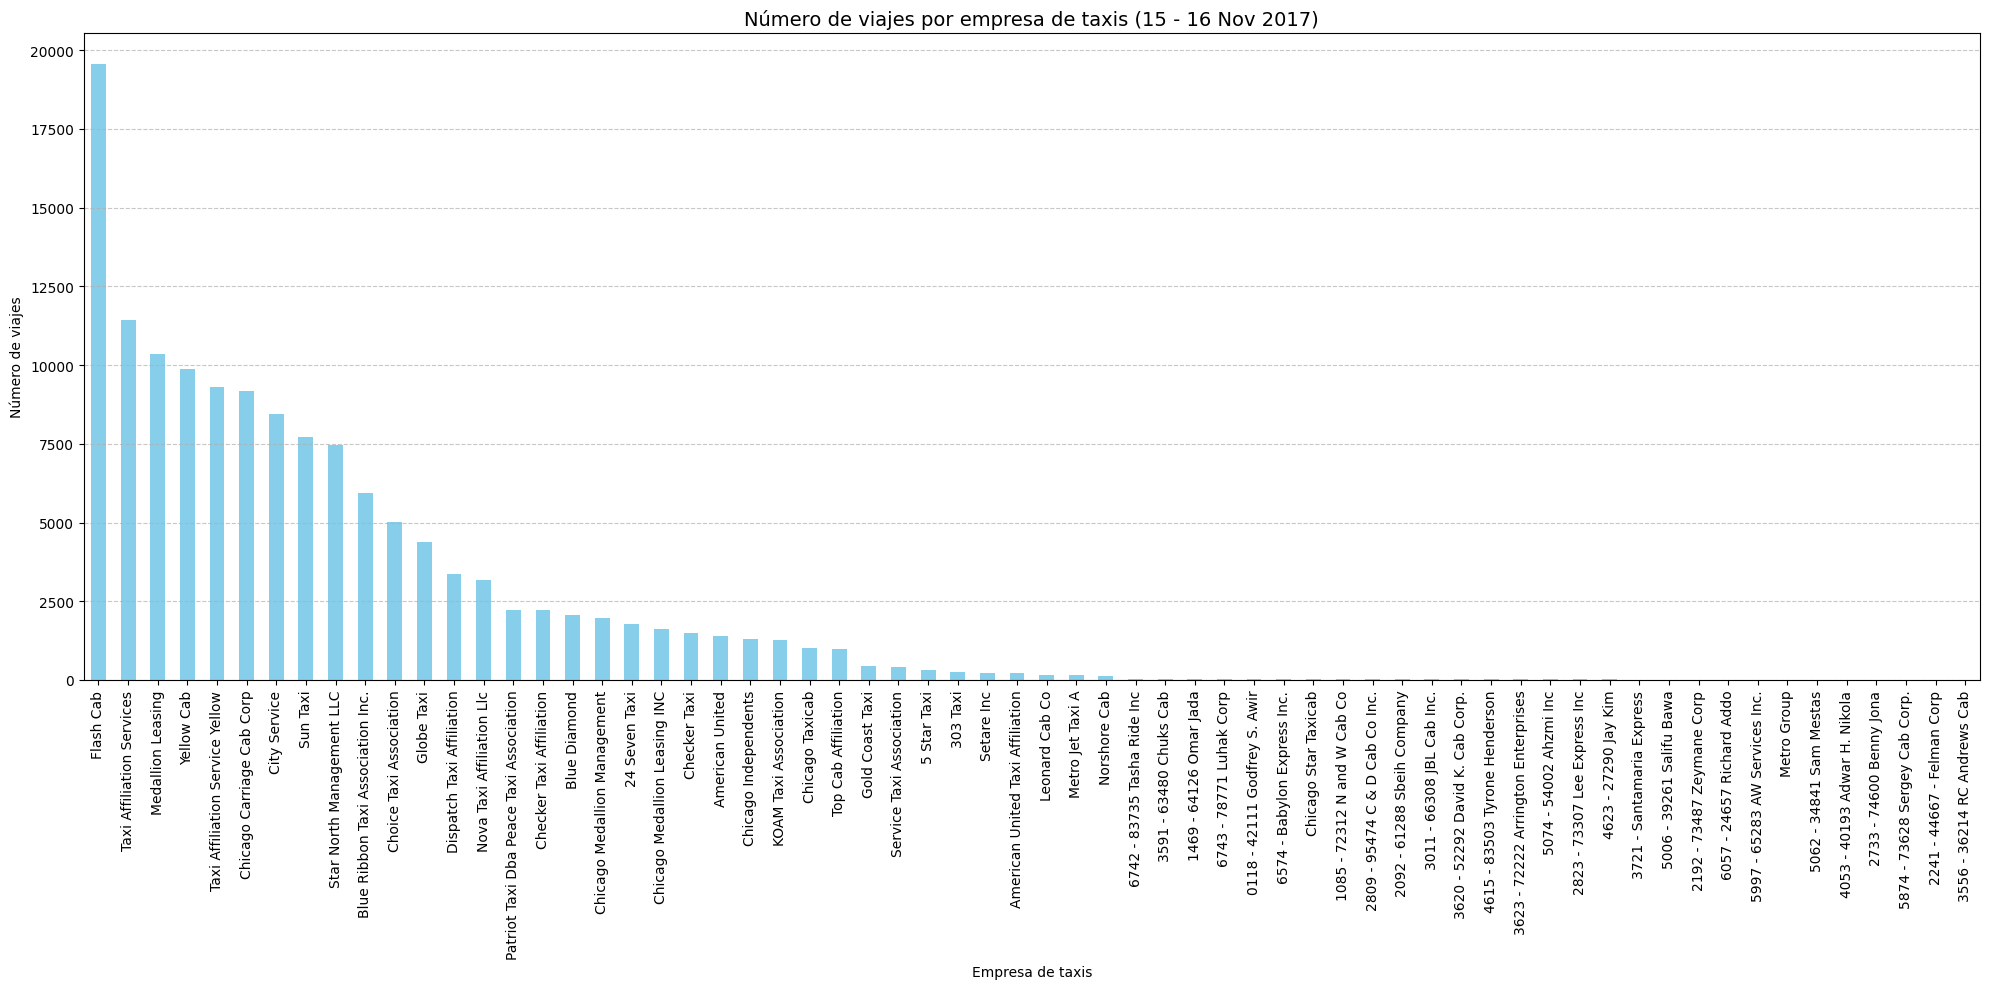

In [ ]:
# Gráfico de número de viajes por empresa de taxis
df_companies.plot(kind = 'bar', x = 'company_name', y = 'trips_amount', figsize = (20, 10), legend = False, color = 'skyblue')

plt.title('Número de viajes por empresa de taxis (15 - 16 Nov 2017)', fontsize = 14)
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.xticks(rotation = 90)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

Podemos observar que el número de viajes registrados para aproximadamente la mitad de las compañías de taxis no es significativo. Por lo tanto, volvamos a trazar el gráfico para las 35 compañías de taxis con mayor actividad.

In [ ]:
df_top_35_companies = df_companies.sort_values(by = 'trips_amount', ascending = False).head(35)

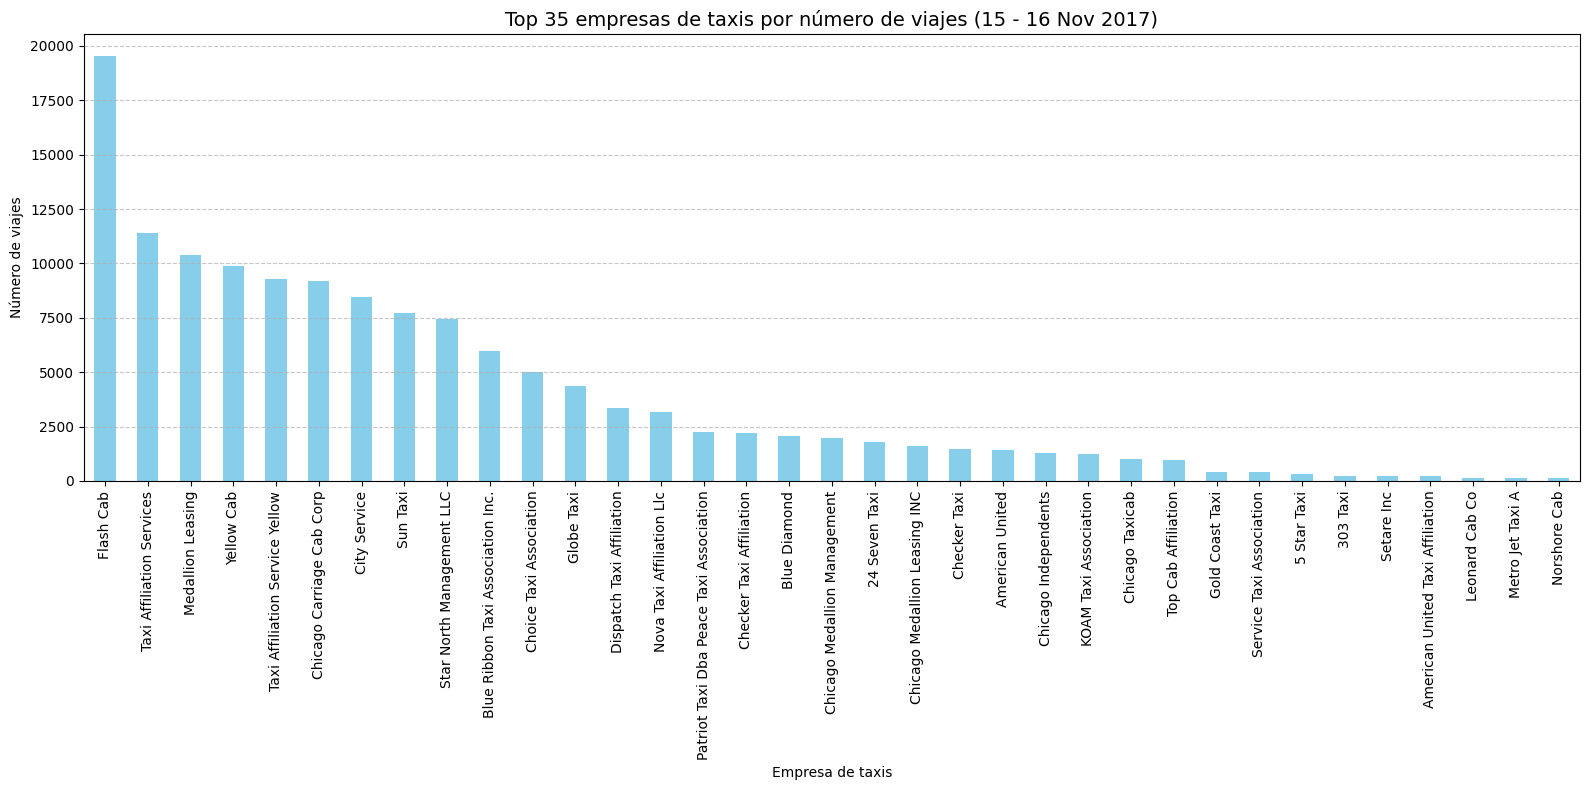

In [ ]:
# Gráfico de las 35 empresas con más viajes
df_top_35_companies.plot(kind = 'bar', x = 'company_name', y = 'trips_amount', figsize = (16, 8), legend = False, color = 'skyblue')

plt.title('Top 35 empresas de taxis por número de viajes (15 - 16 Nov 2017)', fontsize=14)
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.xticks(rotation = 90)
plt.grid(axis = 'y', linestyle = '--', alpha=0.7)
plt.tight_layout()
plt.show()

En este paso, incorporamos los datos de viajes compartidos de Zuber de noviembre de 2017 a nuestro espacio de trabajo y analizamos el contenido de los conjuntos de datos. Descubrimos que la columna de fecha debía convertirse en un objeto de fecha y hora. También identificamos algunos valores estadísticos atípicos, excepto los relacionados con la duración del viaje, que se abordarán en el siguiente paso. Tras evaluar los datos, descubrimos las compañías de taxis y los barrios de destino más populares. Una visualización reveló una diferencia significativa en las cuotas de mercado de las compañías de taxis y los distritos de destino, con compañías como Flash Cab y barrios como Loop y River North superando significativamente a otras.

Presentación del top 10 de las principales empresas con número de viajes.

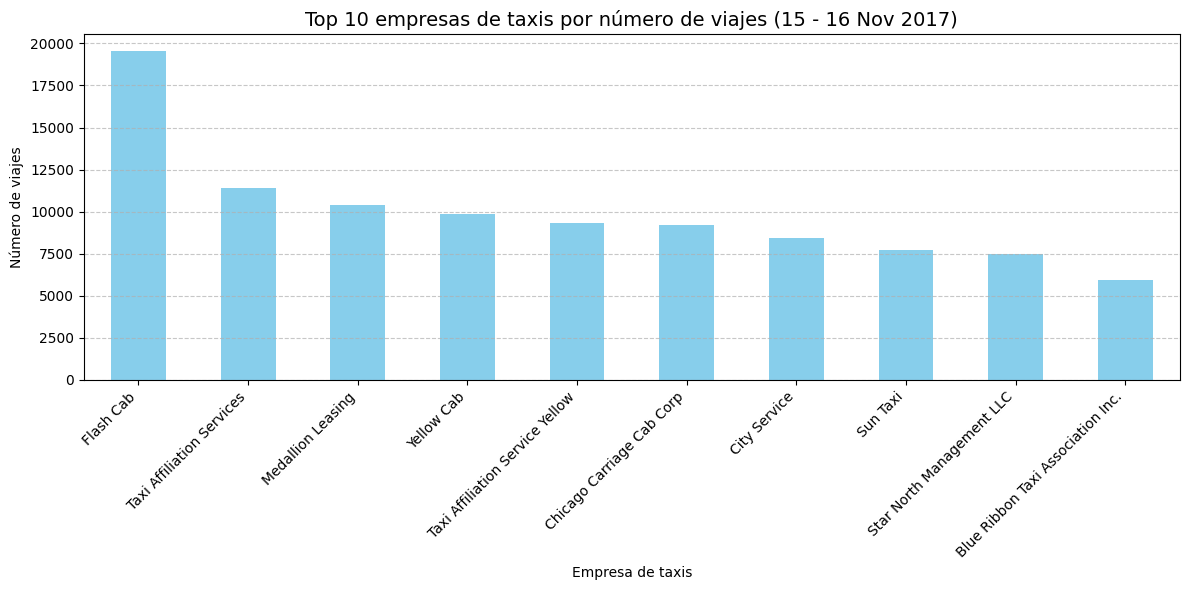

In [ ]:
# Obtener el top 10 de empresas con más viajes
top_10_companies = df_companies.sort_values(by = 'trips_amount', ascending = False).head(10)

# Gráfico de barras para el top 10 de empresas
top_10_companies.plot(kind = 'bar', x = 'company_name', y = 'trips_amount', figsize = (12, 6), legend = False, color = 'skyblue')

plt.title('Top 10 empresas de taxis por número de viajes (15 - 16 Nov 2017)', fontsize = 14)
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

Ahora se presenta una gráfica complementaria que muestra solo el top 10 de empresas de taxis con mayor número de viajes. Esto es especialmente útil para el cliente, ya que permite enfocarse en los principales actores del mercado.


## Formulación de hipótesis

### Prueba de igualdad de varianzas con Levene

Antes de realizar la prueba t para comparar las medias de duración de los viajes, es importante comprobar si ambas muestras (sábados lluviosos y sábados no lluviosos) tienen varianzas iguales.

Para ello, utilizamos la prueba de Levene, que evalúa la igualdad de varianzas. La hipótesis nula de la prueba de Levene es que ambas muestras tienen varianzas iguales.

- Hipótesis nula: Las varianzas de ambas muestras son iguales.
- Hipótesis alternativa: Las varianzas son diferentes.

Usaremos un nivel de significancia de `α = 0.05`.

In [14]:
# Filtrar solo los sábados
saturdays = df_weather_trips[df_weather_trips['start_ts'].dt.dayofweek == 5]

# Separar los sábados según el clima
good_weather = saturdays.query("weather_conditions == 'Good'")['duration_seconds'].dropna()
bad_weather = saturdays.query("weather_conditions == 'Bad'")['duration_seconds'].dropna()

# Nivel de significancia
alpha = 0.05

# Prueba de Levene
levene_test = st.levene(good_weather, bad_weather)
levene_pvalue = levene_test.pvalue

print('Resultado de la prueba de Levene:')
print(f'Valor p: {levene_pvalue}')

# Determinar si asumimos igualdad de varianzas
if levene_pvalue < alpha:
    print('Rechazamos la hipótesis nula: las varianzas son diferentes. equal_var = False')
    equal_var = False
else:
    print('No podemos rechazar la hipótesis nula: las varianzas son iguales. equal_var = True')
    equal_var = True

Resultado de la prueba de Levene:
Valor p: 0.5332038671974493
No podemos rechazar la hipótesis nula: las varianzas son iguales. equal_var = True


### Prueba de hipótesis: ¿Los sábados lluviosos afectan la duración de los viajes?

Queremos probar si la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos. 

- Hipótesis nula: la duración promedio de los viajes los sábados lluviosos es igual a la de los sábados con buen clima.

- Hipótesis alternativa: la duración promedio de los viajes los sábados lluviosos es diferente a la de los sábados con buen clima.

Usaremos una prueba t para muestras independientes porque estamos comparando dos grupos separados (viajes en clima "Bad" vs "Good").

También utilizamos previamente una prueba de Levene para verificar si las varianzas son iguales, lo que nos indica si debemos usar `equal_var = True` o `False` en la prueba t.

Establecemos un nivel de significancia `α = 0.05`.

In [15]:
# Filtrar solo los sábados
saturdays = df_weather_trips[df_weather_trips['start_ts'].dt.dayofweek == 5]

# Dividir entre clima bueno y malo
good_weather = saturdays.query("weather_conditions == 'Good'")
bad_weather = saturdays.query("weather_conditions == 'Bad'")

# Calcular los promedios de duración
mean_good = good_weather['duration_seconds'].mean()
mean_bad = bad_weather['duration_seconds'].mean()

print(f"Duración promedio con clima 'Good': {mean_good} segundos")
print(f"Duración promedio con clima 'Bad': {mean_bad} segundos")

# Nivel de significancia
alpha = 0.05

# Prueba de hipótesis
results = st.ttest_ind(good_weather['duration_seconds'], bad_weather['duration_seconds'], equal_var = equal_var)

print('\nResultado de la prueba t de Student:')
print('Valor p:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula: hay una diferencia significativa en la duración promedio.')
else:
    print('No podemos rechazar la hipótesis nula: no hay evidencia suficiente de una diferencia.')

Duración promedio con clima 'Good': 1999.6756756756756 segundos
Duración promedio con clima 'Bad': 2427.2055555555557 segundos

Resultado de la prueba t de Student:
Valor p: 6.517970327099473e-12
Rechazamos la hipótesis nula: hay una diferencia significativa en la duración promedio.


Se evaluó la hipótesis "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos". Primero, se realizó una prueba de Levene para verificar la igualdad de varianzas, cuyo valor p fue de 0.5332, por lo que no se rechazó la hipótesis nula y se asumió varianza igual. Luego, se aplicó una prueba t de Student con `equal_var = True`, comparando los viajes de sábados con clima bueno y malo. La duración promedio fue de 1999.68 segundos para clima `'Good'` y 2427.21 segundos para clima `'Bad'`. El valor p obtenido fue de 6.52e-12, significativamente menor que el nivel de significancia α = 0.05, por lo tanto, se rechazó la hipótesis nula. En conclusión, existe evidencia estadística suficiente para afirmar que los sábados lluviosos afectan la duración promedio de los viajes, siendo más largos en condiciones climáticas adversas.

## Conclusión general

A lo largo de este proyecto se realizó un análisis exploratorio y estadístico de datos reales sobre viajes en taxi en la ciudad de Chicago, específicamente entre el 15 y 16 de noviembre de 2017. Se trabajó con tres fuentes principales de datos: cantidad de viajes por empresa, barrios con más finalizaciones de recorridos y viajes desde el Loop hasta el Aeropuerto Internacional O’Hare junto con condiciones climáticas.

Se identificaron las empresas de taxis con mayor volumen de viajes, así como los barrios con más promedio de viajes finalizados, lo que permitió visualizar los puntos más activos de la ciudad en términos de movilidad. Estos datos pueden resultar valiosos para decisiones de negocio, distribución de flotas o estrategias logísticas.

En la parte estadística, se analizó si las condiciones climáticas afectaban la duración de los viajes los días sábado. A través de una prueba de Levene y una prueba t de Student, se concluyó que sí existe una diferencia significativa en la duración promedio de los viajes entre días con clima bueno y clima malo, siendo más largos en los días lluviosos.

Este tipo de análisis puede aportar información clave para la optimización de rutas considerando factores como el clima y la demanda por ubicación.